<a href="https://colab.research.google.com/github/hsozpa/aidev/blob/main/%E2%91%A1%E6%9C%80%E7%B5%82%E8%AA%B2%E9%A1%8C_%E3%82%AA%E3%83%AA%E3%82%B8%E3%83%8A%E3%83%ABAI%E3%81%AE%E6%A7%8B%E7%AF%89.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 必要なライブラリのimport
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import tensorflow as tf

from sklearn.model_selection import train_test_split

In [ ]:
# データの読み込み
(X_train, Y_train), (X_test, Y_test) = tf.keras.datasets.cifar10.load_data()

In [ ]:
# データの確認

print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


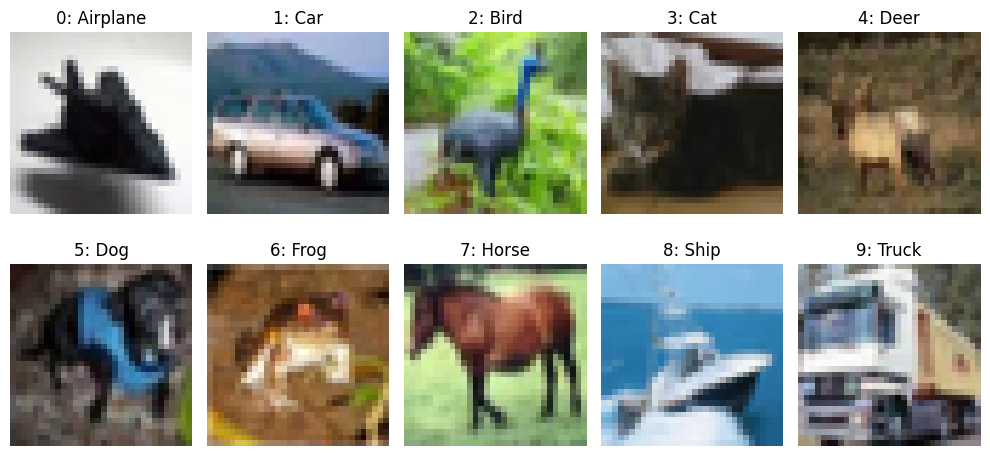

In [ ]:
class_names = ['Airplane', 'Car', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

plt.figure(figsize=(10, 5))
for i, label in enumerate(range(10)):
    idx = np.where(Y_train.flatten() == label)[0][0]
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[idx])
    plt.title(f"{label}: {class_names[label]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# データの前処理

# DeerとHorseを抽出
target_classes = [4, 7]
mask_train = np.isin(Y_train,target_classes)
mask_test = np.isin(Y_test, target_classes)

X = np.concatenate([X_train[mask_train.flatten()], X_test[mask_test.flatten()]])
Y = np.concatenate([Y_train[mask_train.flatten()], Y_test[mask_test.flatten()]])

#二値化
Y = np.where(Y == 4, 0, 1)
print(Y)

[[0]
 [1]
 [0]
 ...
 [1]
 [1]
 [1]]


In [ ]:
# 各データの枚数
print("【訓練データ】")
print("Deer :", np.sum(Y_train == 4))
print("Horse:", np.sum(Y_train == 7))

print("\n【テストデータ】")
print("Deer :", np.sum(Y_test == 4))
print("Horse:", np.sum(Y_test == 7))

【訓練データ】
Deer : 5000
Horse: 5000

【テストデータ】
Deer : 1000
Horse: 1000


In [ ]:
# 正規化
X = X.astype("float32") / 255.0

In [ ]:
# データの分割
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=0)
X_train, X_valid, Y_train, Y_valid = train_test_split(X_train, Y_train, test_size=0.3, random_state=0)

In [ ]:
# 形状を確認
print("Y_train=", Y_train.shape, ", X_train=", X_train.shape)
print("Y_valid=", Y_valid.shape, ", X_valid=", X_valid.shape)
print("Y_test=", Y_test.shape, ", X_test=", X_test.shape)

Y_train= (5880, 1) , X_train= (5880, 32, 32, 3)
Y_valid= (2520, 1) , X_valid= (2520, 32, 32, 3)
Y_test= (3600, 1) , X_test= (3600, 32, 32, 3)


In [ ]:
# モデルの初期化
model = tf.keras.Sequential([
    tf.keras.Input(shape=(32, 32, 3)),

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    # 追加層（より深く）
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),

    # Dropoutを加えると過学習を防げる
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(1, activation='sigmoid')
])


# モデルの構築
# model.compile(optimizer = "rmsprop", loss='categorical_crossentropy', metrics=['accuracy'])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # ← 学習率を少し下げる
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# モデルの構造を表示
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 159,041 (621.25 KB)

 Trainable params: 159,041 (621.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
%%time
# 学習の実施
log = model.fit(
    X_train, Y_train,
    epochs=5000,
    batch_size=64,
    verbose=True,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            min_delta=0,
            patience=50,
            verbose=1,
            restore_best_weights=True
        )
    ],
    validation_data=(X_test, Y_test)
)

Epoch 1/5000
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.5402 - loss: 0.6783 - val_accuracy: 0.6858 - val_loss: 0.6343
Epoch 2/5000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6976 - loss: 0.6072 - val_accuracy: 0.7231 - val_loss: 0.5611
Epoch 3/5000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7343 - loss: 0.5397 - val_accuracy: 0.7261 - val_loss: 0.5430
Epoch 4/5000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7634 - loss: 0.5061 - val_accuracy: 0.7492 - val_loss: 0.5111
Epoch 5/5000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7606 - loss: 0.4982 - val_accuracy: 0.7608 - val_loss: 0.4896
Epoch 6/5000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7796 - loss: 0.4736 - val_accuracy: 0.7781 - val_loss: 0.4670
Epoch 7/5000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7880 - loss: 0.4528 - val_accuracy: 0.7700 - val_loss: 0.4774
Epoch 8/5000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7890 - loss: 0.4478 - val_accuracy: 0

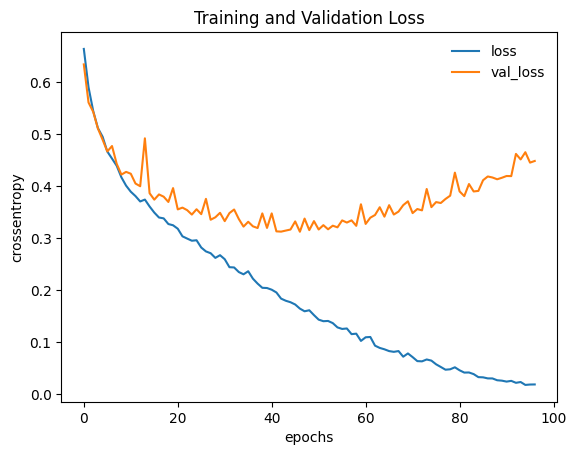

In [ ]:
# グラフ表示
plt.plot(log.history['loss'], label='loss')
plt.plot(log.history['val_loss'], label='val_loss')
plt.legend(frameon=False)  # 凡例（loss, val_loss）を表示
plt.xlabel("epochs")
plt.ylabel("crossentropy")
plt.title("Training and Validation Loss")
plt.show()

In [ ]:
# predictで予測を行なう
Y_pred = model.predict(X_test)

113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [ ]:
Y_pred

array([[0.86691296],
       [0.9245748 ],
       [0.02106048],
       ...,
       [0.99203   ],
       [0.6452685 ],
       [0.08110201]], dtype=float32)

In [ ]:
# 二値分類は予測結果の確率が0.5以下なら0,それより大きければ1となる計算で求める
Y_pred_classes = (Y_pred > 0.5).astype("int32")
Y_pred_classes

array([[1],
       [1],
       [0],
       ...,
       [1],
       [1],
       [0]], dtype=int32)

In [ ]:
# 形状を正解（目的変数）に合わせる
Y_pred_ = Y_pred_classes.reshape(-1)
Y_test_ = Y_test.reshape(-1)

In [ ]:
# モデルの評価
from sklearn.metrics import classification_report

print(classification_report(Y_test_, Y_pred_))

              precision    recall  f1-score   support

           0       0.87      0.89      0.88      1856
           1       0.88      0.85      0.87      1744

    accuracy                           0.87      3600
   macro avg       0.87      0.87      0.87      3600
weighted avg       0.87      0.87      0.87      3600



# 不正解だったものを確認する

In [ ]:
# ① 予測確率とクラス判定を作成
Y_pred = model.predict(X_test)
Y_pred_cls = (Y_pred > 0.5).astype("int32")
Y_pred_flat = Y_pred_cls.reshape(-1)
Y_test_flat = Y_test.reshape(-1)

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
# ② 不正解インデックスを抽出
wrong_indices = np.where(Y_pred_flat != Y_test_flat)[0]
print("間違えたサンプル数：", len(wrong_indices))

間違えたサンプル数： 465


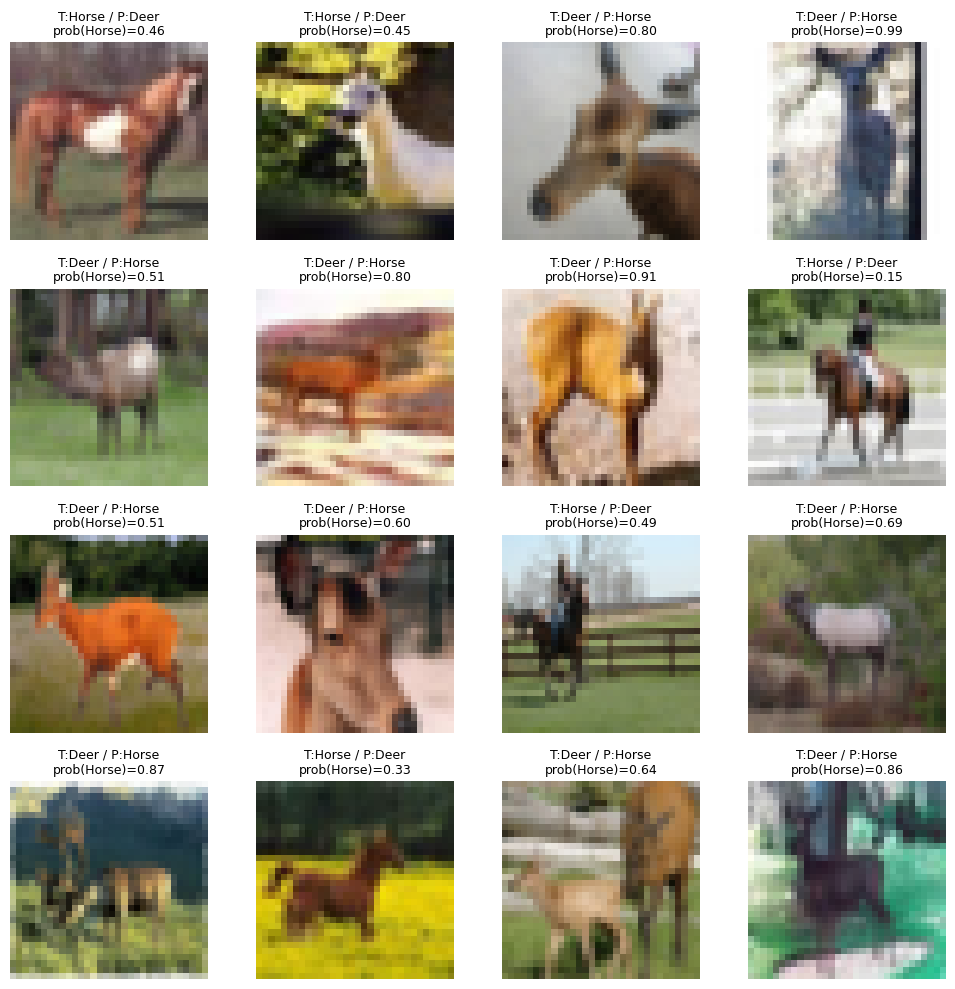

In [ ]:
# ③ 不正解の画像を可視化

label_names = {0: 'Deer', 1: 'Horse'}
num_show = min(16, len(wrong_indices))

plt.figure(figsize=(10, 10))
for i in range(num_show):
  idx = wrong_indices[i]
  img = X_test[idx]
  t_label = Y_test_flat[idx]
  p_label = Y_pred_flat[idx]
  prob = Y_pred[idx][0]

  plt.subplot(4, 4, i + 1)
  plt.imshow(img)
  plt.axis('off')
  plt.title(f"T:{label_names[t_label]} / P:{label_names[p_label]}\nprob(Horse)={prob:.2f}",
        fontsize=9
  )

plt.tight_layout()
plt.show()
